In [2]:
import pandas as pd
import os

filename = "AB_NYC_2019.csv"

# Check if file exists before trying to open it
if not os.path.exists(filename):
    print(f"ERROR: '{filename}' not found in the current folder!")
else:
    # 1. Load data
    df = pd.read_csv(filename)

    # 2. Fill missing reviews with 0
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

    # 3. Clean names and drop duplicates
    df = df.dropna(subset=["name", "host_name"]).copy()
    df = df.drop_duplicates()

    # 4. Filter prices (using .copy() to avoid warnings)
    df = df[(df["price"] > 0) & (df["price"] < 1000)].copy()

    # 5. Safe Date Conversion
    # We use 'errors=coerce' so that if a date is unreadable, it becomes 'NaT' (Not a Time)
    # instead of crashing the whole script.
    df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

    # 6. Final check for any remaining Nulls
    print("--- Missing Values Per Column ---")
    print(df.isnull().sum())

    # 7. Save
    df.to_csv("cleaned_airbnb.csv", index=False)
    print("\nSuccess! Cleaned file saved as 'cleaned_airbnb.csv'")
    print(f"Final Row Count: {len(df)}")

--- Missing Values Per Column ---
id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9875
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
dtype: int64

Success! Cleaned file saved as 'cleaned_airbnb.csv'
Final Row Count: 48549


C:\Users\HomePC\AppData\Local\Temp\ipykernel_17024\12745030.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)
C:\Users\HomePC\AppData\Local\Temp\ipykernel_17024\12745030.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

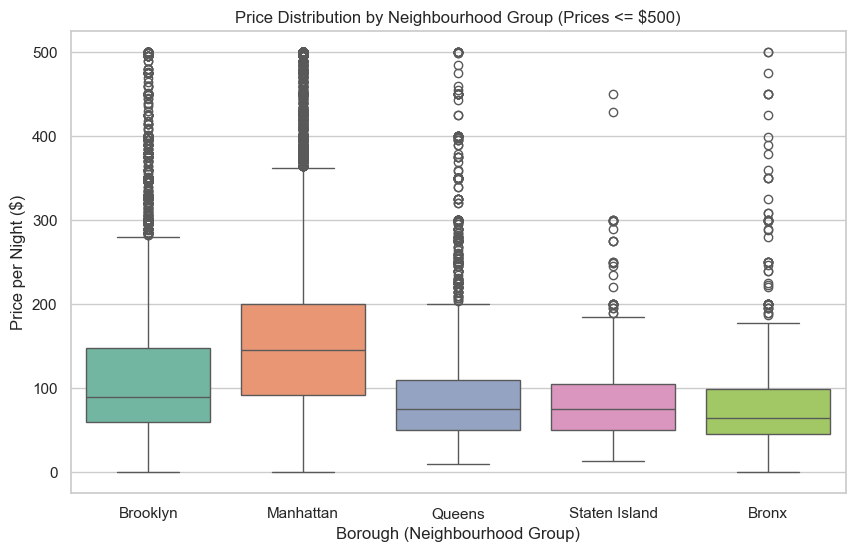

C:\Users\HomePC\AppData\Local\Temp\ipykernel_17024\12745030.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df, palette='viridis', order=df['room_type'].value_counts().index)


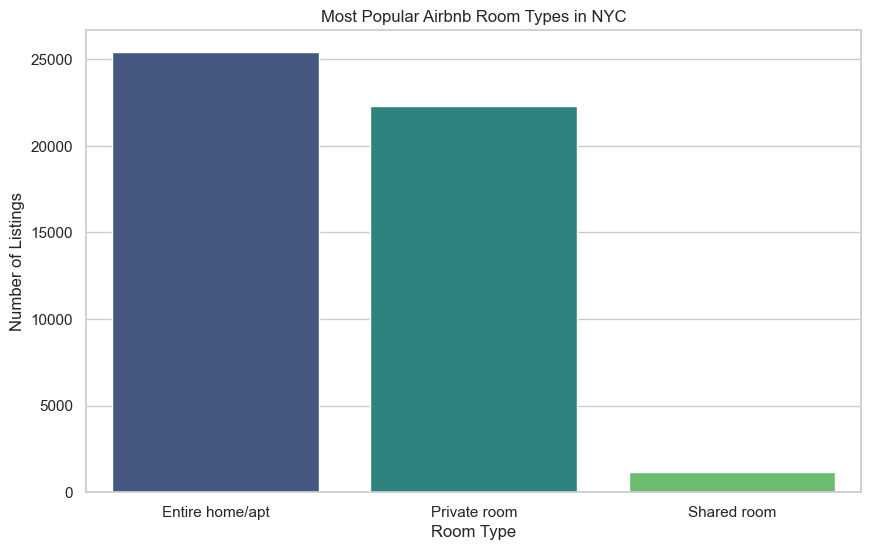

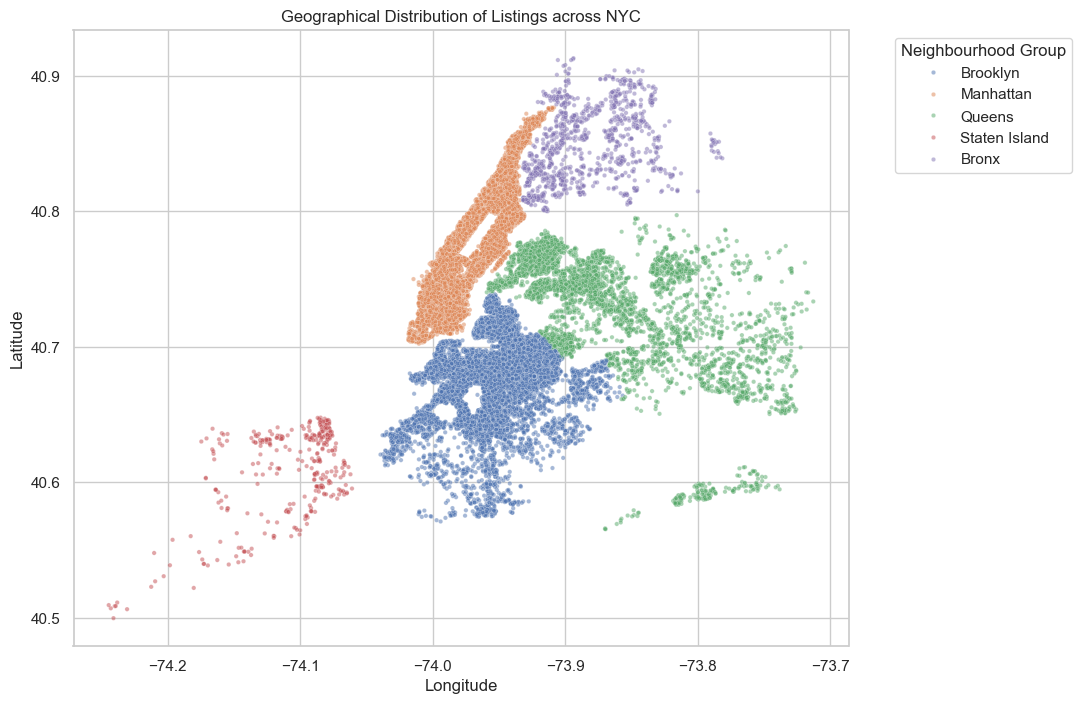

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND CLEAN THE DATA
# Ensure the 'AB_NYC_2019.csv' file from Kaggle is in your current folder
df = pd.read_csv('AB_NYC_2019.csv')

# Handling missing values (Clean the data task)
df['reviews_per_month'].fillna(0, inplace=True)
df['name'].fillna('Unknown', inplace=True)
df['host_name'].fillna('Unknown', inplace=True)
df['last_review'].fillna('None', inplace=True)

# 2. VISUALISATIONS
sns.set(style="whitegrid")

# VISUALISATION 1: Price Distribution across Neighbourhood Groups
plt.figure(figsize=(10, 6))
# Removing extreme price outliers (above $500) for a clearer boxplot
sns.boxplot(x='neighbourhood_group', y='price', data=df[df['price'] <= 500], palette='Set2')
plt.title('Price Distribution by Neighbourhood Group (Prices <= $500)')
plt.xlabel('Borough (Neighbourhood Group)')
plt.ylabel('Price per Night ($)')
plt.show()

# VISUALISATION 2: Count of Listings by Room Type
plt.figure(figsize=(10, 6))
# Sorted by most popular room type
sns.countplot(x='room_type', data=df, palette='viridis', order=df['room_type'].value_counts().index)
plt.title('Most Popular Airbnb Room Types in NYC')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.show()

# VISUALISATION 3: Geographical Map of Listings
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='neighbourhood_group', data=df, s=10, alpha=0.5)
plt.title('Geographical Distribution of Listings across NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighbourhood Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()